In [ ]:
! pip install bitsandbytes accelerate

In [ ]:
MODEL_ID = "google/paligemma2-3b-mix-224"
TASK = "image-text-to-text" # vlm category

In [ ]:
from transformers import AutoProcessor , BitsAndBytesConfig , PaliGemmaForConditionalGeneration ,PaliGemmaProcessor
import torch
from PIL import Image
import requests

In [ ]:
device = "cuda:0"
dtype = torch.bfloat16

In [ ]:
quantization_config = BitsAndBytesConfig(load_in_4bit=True)
quantization_config # to reduce the weights size in memory

In [ ]:
model = PaliGemmaForConditionalGeneration.from_pretrained(
    pretrained_model_name_or_path = MODEL_ID,
    dtype = dtype,
    quantization_config = quantization_config
)
processor = PaliGemmaProcessor.from_pretrained(MODEL_ID)

In [ ]:
## buliding and object deteaction model (inference) with pali gemma is easy

## to detect object prompt follows :  "detect [classname]" >> classname is what we want to detect
## to detect multiple classes in single image  : "detect [class1];[class2];[class3]"

## it return in boundig box format like <loc122><loc234><loc402><loc422> class1; >> this is the normalized format of [y_min,x_min,y_max,x_max]
## as this is normalized form we want to futher preprocesses it

In [ ]:
url = "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/transformers/tasks/car.jpg"
image = Image.open(requests.get(url=url,stream=True).raw)

In [ ]:
prompt = "detect car"
model = model.to(device)
model_input = processor(images=image,text = prompt , return_tensors = "pt").to(torch.bfloat16).to(model.device)
model_ids = model_input["input_ids"].shape[-1] # this is required when to format the output generated by model

In [ ]:
## inferencing model
model = model.eval()
with torch.inference_mode():
  outputs = model.generate(**model_input,max_new_tokens=200,do_sample=False)
  outputs = outputs[0][model_ids:]
  decoded = processor.decode(outputs,skip_special_tokens=True)
  print(decoded)

In [ ]:
decoded

In [ ]:
import re
bbox = re.findall(r"\d+\.?\d*", decoded)

In [ ]:
bbox ## string

In [ ]:
## re normalizing values
## converting to integer
bbox = [int(val) for val in bbox]
bbox

In [ ]:
W,H = image.size
W,H

In [ ]:
# Fixed and cleaned version
scaled_bbox = []
for i, val in enumerate(bbox):
    if i % 2 == 0:  # y_min, y_max (y-axis)
        scaled_bbox.append((val / 1024) * H)
    else:           # x_min, x_max (x-axis)
        scaled_bbox.append((val / 1024) * W)

bbox = scaled_bbox

In [ ]:
bbox # not it is ready

In [ ]:
## displaing image and bounding boxes
from torchvision.ops import box_convert
from torchvision.transforms.functional import to_pil_image , pil_to_tensor
from torchvision.utils import draw_bounding_boxes

In [ ]:
bbox = torch.tensor(bbox)
bbox = bbox[...,[1,0,3,2]] # xyxx format for pil image
bbox

In [ ]:
# bbox = bbox.to(torch.int64)
# bbox

In [ ]:
color_palette = {
    "class1": (0, 0, 224)
}
label = "car"
print(next(iter(color_palette)))
labels = [label]
color_labels = [color_palette[next(iter(color_palette))]]
print(labels)
print(color_labels)

In [ ]:
bbox_tensor = torch.tensor(bbox).unsqueeze(0).long()
to_pil_image(
    pic = draw_bounding_boxes(
        image = pil_to_tensor(image),
        boxes = bbox.clone().detach().unsqueeze(0).long(),
        labels = labels,
        colors = color_labels,
        label_colors= color_labels,
        width = 2
    )
)

!!! object detection task complete

### lets build inference code

In [ ]:
from huggingface_hub import login
login()

In [ ]:
from transformers.utils.attention_visualizer import AttentionMaskVisualizer


visualizer = AttentionMaskVisualizer("google/paligemma2-3b-mix-224")
visualizer("<img> What is in this image?")

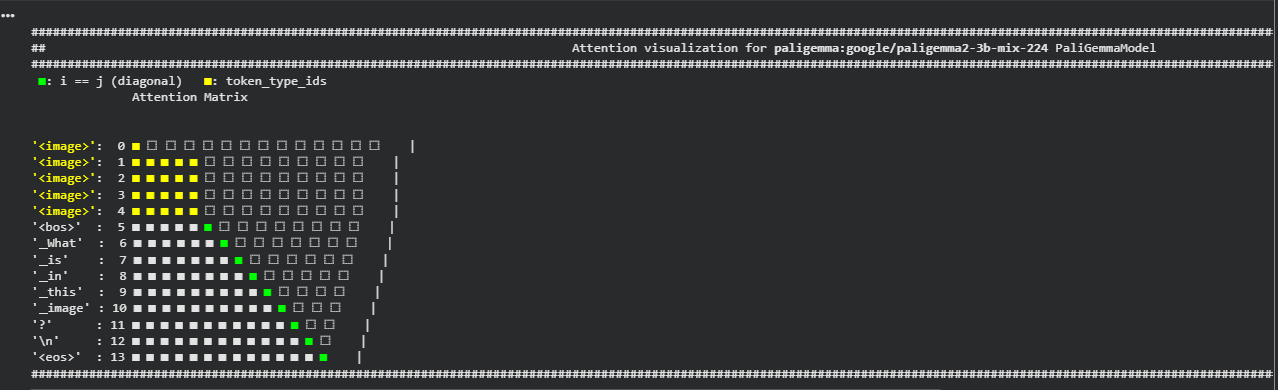